# Nav2 Local Planner Benchmark — Analysis Notebook

This notebook loads six CSV files (three controllers × two conditions) and produces all
summary statistics, statistical tests, and figures used in the report.

**Required input files** (in the `DATA_DIR` set below):
- `dwb_corridor_static.csv`, `mppi_corridor_static.csv`, `rpp_corridor_static.csv`
- `dwb_corridor_dynamic.csv`, `mppi_corridor_dynamic.csv`, `rpp_corridor_dynamic.csv`

Each CSV must have these columns:
`run_id, trial_idx, start_x, start_y, start_yaw, goal_x, goal_y, goal_yaw,
success, timeout, time_to_goal, path_length, path_efficiency, straight_line,
min_clearance, mean_jerk, n_close_approach`

To re-run on different data, change `DATA_DIR` below. Everything else is automatic.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
# ===== Configuration =====
from pathlib import Path

DATA_DIR  = Path('.')          # folder containing the 6 CSVs
OUTPUT_DIR = Path('figures')   # figures get saved here
OUTPUT_DIR.mkdir(exist_ok=True)

CONTROLLERS = ['dwb', 'mppi', 'rpp']
CONDITIONS  = ['static', 'dynamic']

# Display colors for the three controllers
COLORS = {'DWB': '#1f77b4', 'MPPI': '#ff7f0e', 'RPP': '#2ca02c'}

# Safety threshold (m). robot_radius (0.22) + obstacle_radius (0.15) = 0.37 is contact;
# values < 0.30 m are flagged as close-approach events at trial-logging time.
CONTACT_DIST = 0.37

In [17]:
# ===== Imports =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.dpi']      = 110
plt.rcParams['savefig.dpi']     = 150
plt.rcParams['axes.labelsize']  = 10
plt.rcParams['axes.titlesize']  = 11
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

In [18]:
import os
print(os.getcwd())

/content


## 1. Load all six CSVs

Each file is read, tagged with `controller` and `condition`, and concatenated into one tidy
DataFrame. This is the canonical format used by the rest of the notebook.

In [21]:
dfs = {}
for ctrl in CONTROLLERS:
    for cond in CONDITIONS:
        path = DATA_DIR / f'{ctrl}_corridor_{cond}.csv'
        df = pd.read_csv(path)
        df['controller'] = ctrl.upper()
        df['condition']  = cond
        dfs[(ctrl, cond)] = df
        print(f'Loaded {path.name}: {len(df)} trials')

all_df = pd.concat(dfs.values(), ignore_index=True)
print(f'\nTotal trials in combined DataFrame: {len(all_df)}')
all_df.head()

Loaded dwb_corridor_static.csv: 20 trials
Loaded dwb_corridor_dynamic.csv: 20 trials
Loaded mppi_corridor_static.csv: 20 trials
Loaded mppi_corridor_dynamic.csv: 20 trials
Loaded rpp_corridor_static.csv: 20 trials
Loaded rpp_corridor_dynamic.csv: 20 trials

Total trials in combined DataFrame: 120


,run_id,trial_idx,start_x,start_y,start_yaw,goal_x,goal_y,goal_yaw,success,timeout,time_to_goal,path_length,path_efficiency,straight_line,min_clearance,mean_jerk,n_close_approach,controller,condition
0,dwb_corridor_static_001,1,2.15,6.09,-0.21,-0.16,0.15,0.0,True,False,48.009,7.5073,0.8490,6.3734,0.8881,0.5094,0,DWB,static
1,dwb_corridor_static_001,2,-7.23,-0.40,1.07,-3.79,0.43,0.0,True,False,24.900,3.7573,0.9418,3.5387,0.7773,0.5571,0,DWB,static
2,dwb_corridor_static_001,3,-1.10,1.16,-0.71,0.49,5.34,0.0,True,False,34.237,4.9689,0.9000,4.4722,0.9279,0.6115,0,DWB,static
3,dwb_corridor_static_001,4,-0.13,2.40,-2.42,-2.68,-0.31,0.0,True,False,30.032,4.2587,0.8738,3.7211,0.9886,0.4798,0,DWB,static
4,dwb_corridor_static_001,5,0.74,0.49,-1.30,-8.80,0.89,0.0,True,False,66.210,10.3223,0.9250,9.5484,1.2478,0.5351,0,DWB,static


## 2. Summary table

Per-cell median and IQR for each metric. Reproduces Table 1 of the report.

In [22]:
def fmt_iqr(x):
    if len(x) == 0:
        return '-'
    return f'{np.median(x):.1f} [{np.quantile(x, 0.25):.1f}-{np.quantile(x, 0.75):.1f}]'

rows = []
for cond in CONDITIONS:
    for ctrl in CONTROLLERS:
        df = dfs[(ctrl, cond)]
        s  = df[df['success']]
        rows.append({
            'Controller': ctrl.upper(),
            'Condition':  cond,
            'Success':    f"{df['success'].sum()}/{len(df)}",
            'Time (s)':       fmt_iqr(s['time_to_goal']),
            'Path eff.':      fmt_iqr(s['path_efficiency']),
            'Clearance (m)':  fmt_iqr(s['min_clearance']),
            'Jerk':           fmt_iqr(s['mean_jerk']),
            'Close appr.':    int(df['n_close_approach'].sum()),
        })
summary = pd.DataFrame(rows)
summary.to_csv(OUTPUT_DIR / 'summary_table.csv', index=False)
summary

,Controller,Condition,Success,Time (s),Path eff.,Clearance (m),Jerk,Close appr.
0,DWB,static,20/20,41.2 [35.0-56.8],0.9 [0.9-0.9],0.9 [0.7-1.0],0.5 [0.4-0.6],0
1,MPPI,static,20/20,31.1 [21.5-39.3],1.0 [0.9-1.0],0.8 [0.6-1.1],0.5 [0.5-0.6],0
2,RPP,static,20/20,31.6 [24.4-41.0],1.0 [1.0-1.0],0.7 [0.6-0.8],0.6 [0.5-0.6],2
3,DWB,dynamic,19/20,56.7 [43.9-79.0],0.8 [0.8-0.9],0.8 [0.6-0.9],0.7 [0.6-0.8],3
4,MPPI,dynamic,19/20,37.5 [26.0-44.9],0.9 [0.9-1.0],0.6 [0.5-0.7],0.8 [0.7-0.8],12
5,RPP,dynamic,20/20,41.6 [29.1-48.9],1.0 [0.9-1.0],0.5 [0.4-0.6],0.8 [0.8-0.9],19


## 3. Figure 1 — Success rate

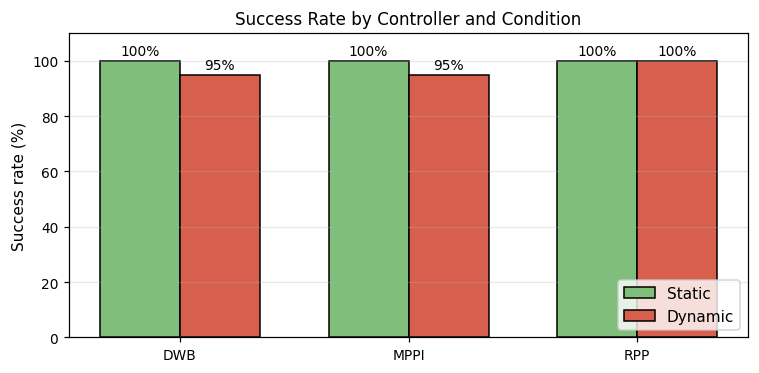

In [23]:
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(3); w = 0.35
static_succ = [dfs[(c, 'static')]['success'].mean()*100  for c in CONTROLLERS]
dyn_succ    = [dfs[(c, 'dynamic')]['success'].mean()*100 for c in CONTROLLERS]
ax.bar(x - w/2, static_succ, w, label='Static',  color='#7fbf7b', edgecolor='black')
ax.bar(x + w/2, dyn_succ,    w, label='Dynamic', color='#d6604d', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels([c.upper() for c in CONTROLLERS])
ax.set_ylabel('Success rate (%)')
ax.set_ylim(0, 110)
ax.set_title('Success Rate by Controller and Condition')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
for i, (s, d) in enumerate(zip(static_succ, dyn_succ)):
    ax.text(i - w/2, s+2, f'{s:.0f}%', ha='center', fontsize=9)
    ax.text(i + w/2, d+2, f'{d:.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_success.png', bbox_inches='tight')
plt.show()

## 4. Figure 2 — Time-to-goal distributions (violin plots)

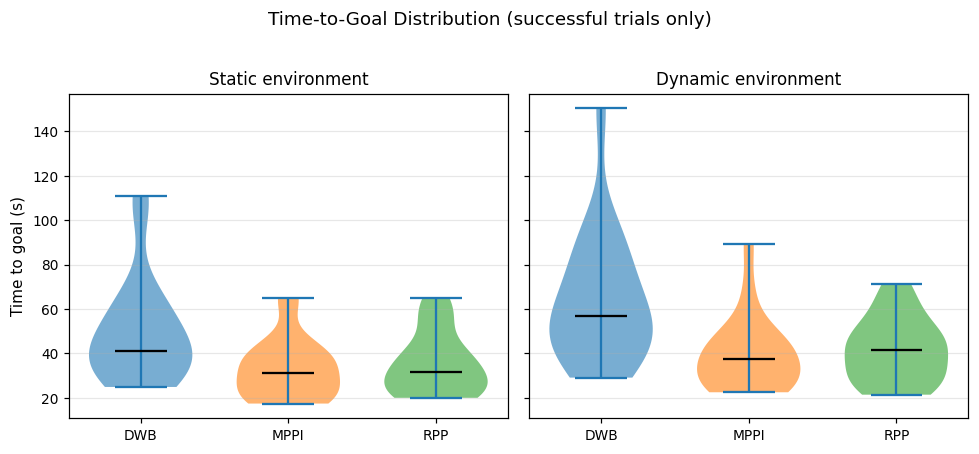

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, cond in zip(axes, CONDITIONS):
    data = [dfs[(c, cond)].query('success')['time_to_goal'].values for c in CONTROLLERS]
    parts = ax.violinplot(data, showmeans=False, showmedians=True, widths=0.7)
    for pc, c in zip(parts['bodies'], CONTROLLERS):
        pc.set_facecolor(COLORS[c.upper()]); pc.set_alpha(0.6)
    parts['cmedians'].set_color('black')
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels([c.upper() for c in CONTROLLERS])
    ax.set_title(f'{cond.capitalize()} environment')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('Time to goal (s)')
fig.suptitle('Time-to-Goal Distribution (successful trials only)', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_time.png', bbox_inches='tight')
plt.show()

## 5. Figure 3 — Path efficiency

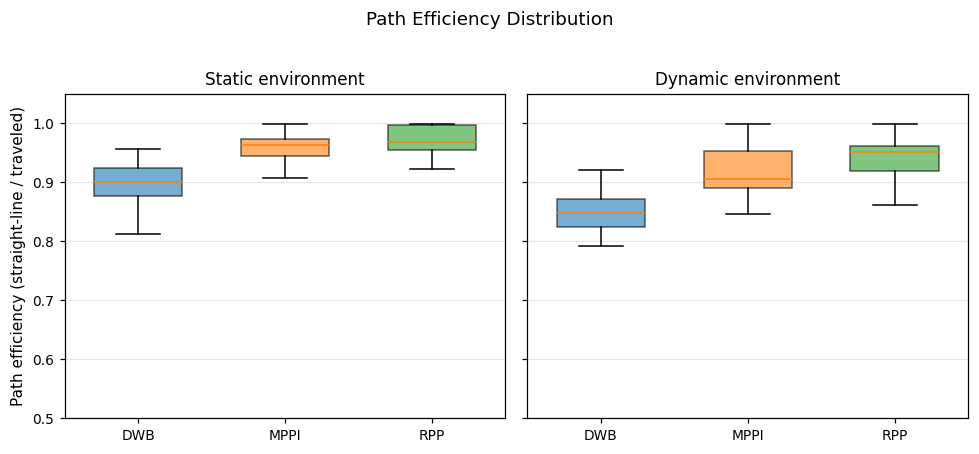

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, cond in zip(axes, CONDITIONS):
    data = [dfs[(c, cond)].query('success')['path_efficiency'].values for c in CONTROLLERS]
    bp = ax.boxplot(data, tick_labels=[c.upper() for c in CONTROLLERS],
                    patch_artist=True, widths=0.6)
    for patch, c in zip(bp['boxes'], CONTROLLERS):
        patch.set_facecolor(COLORS[c.upper()]); patch.set_alpha(0.6)
    ax.set_title(f'{cond.capitalize()} environment')
    ax.grid(axis='y', alpha=0.3); ax.set_ylim(0.5, 1.05)
axes[0].set_ylabel('Path efficiency (straight-line / traveled)')
fig.suptitle('Path Efficiency Distribution', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_efficiency.png', bbox_inches='tight')
plt.show()

## 6. Figure 4 — Safety (clearance and close-approach events)

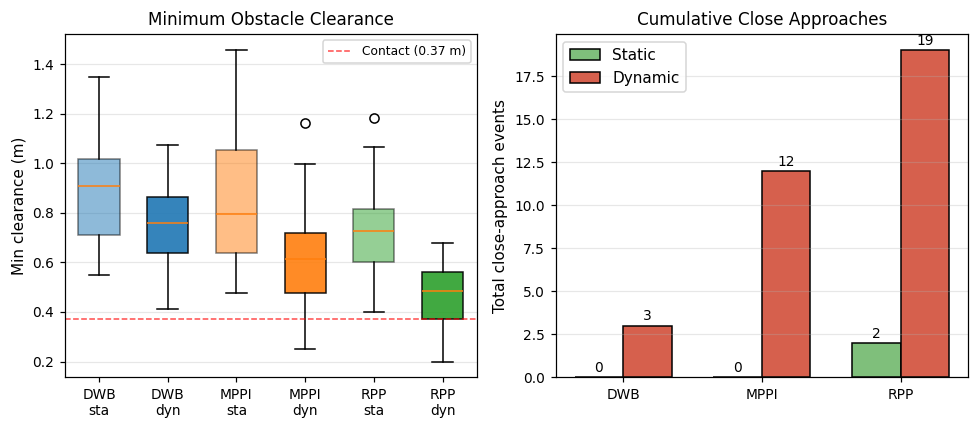

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Left: clearance distributions, all six cells
ax = axes[0]
data = []; labels = []
for c in CONTROLLERS:
    for cond in CONDITIONS:
        data.append(dfs[(c, cond)].query('success')['min_clearance'].values)
        labels.append(f'{c.upper()}\n{cond[:3]}')
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.6)
for patch, lab in zip(bp['boxes'], labels):
    ctrl, cond = lab.split('\n')
    patch.set_facecolor(COLORS[ctrl])
    patch.set_alpha(0.5 if cond == 'sta' else 0.9)
ax.axhline(CONTACT_DIST, color='red', linestyle='--', linewidth=1,
           alpha=0.7, label=f'Contact ({CONTACT_DIST} m)')
ax.set_ylabel('Min clearance (m)')
ax.set_title('Minimum Obstacle Clearance')
ax.legend(loc='upper right', fontsize=8); ax.grid(axis='y', alpha=0.3)

# Right: cumulative close-approach counts
ax = axes[1]
totals = []
for cond in CONDITIONS:
    row = [dfs[(c, cond)]['n_close_approach'].sum() for c in CONTROLLERS]
    totals.append(row)
x = np.arange(3); w = 0.35
ax.bar(x - w/2, totals[0], w, label='Static',  color='#7fbf7b', edgecolor='black')
ax.bar(x + w/2, totals[1], w, label='Dynamic', color='#d6604d', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels([c.upper() for c in CONTROLLERS])
ax.set_ylabel('Total close-approach events')
ax.set_title('Cumulative Close Approaches')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for i, (s, d) in enumerate(zip(totals[0], totals[1])):
    ax.text(i - w/2, s+0.3, str(int(s)), ha='center', fontsize=9)
    ax.text(i + w/2, d+0.3, str(int(d)), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_safety.png', bbox_inches='tight')
plt.show()

## 7. Figure 5 — Smoothness and degradation

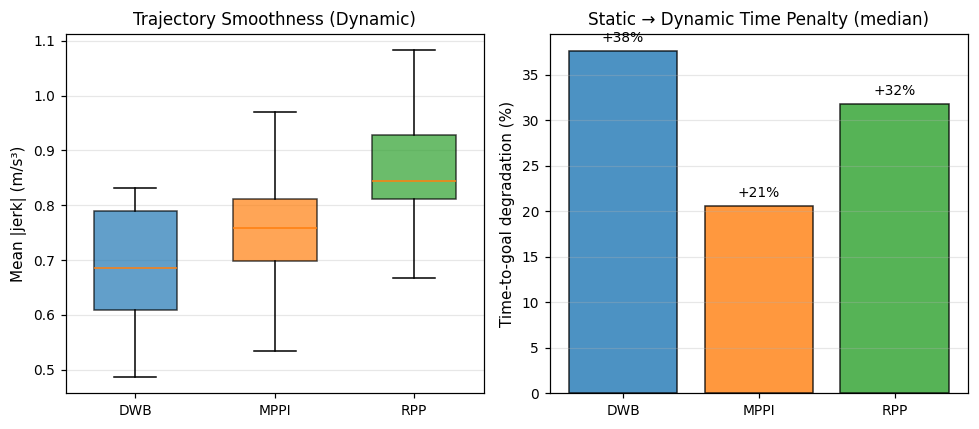

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Left: mean jerk in dynamic
ax = axes[0]
data = [dfs[(c, 'dynamic')].query('success')['mean_jerk'].values for c in CONTROLLERS]
bp = ax.boxplot(data, tick_labels=[c.upper() for c in CONTROLLERS],
                patch_artist=True, widths=0.6)
for patch, c in zip(bp['boxes'], CONTROLLERS):
    patch.set_facecolor(COLORS[c.upper()]); patch.set_alpha(0.7)
ax.set_ylabel('Mean |jerk| (m/s³)')
ax.set_title('Trajectory Smoothness (Dynamic)')
ax.grid(axis='y', alpha=0.3)

# Right: time degradation
ax = axes[1]
stat_med = [dfs[(c, 'static')].query('success')['time_to_goal'].median()  for c in CONTROLLERS]
dyn_med  = [dfs[(c, 'dynamic')].query('success')['time_to_goal'].median() for c in CONTROLLERS]
deg = [(d - s)/s * 100 for s, d in zip(stat_med, dyn_med)]
bars = ax.bar([c.upper() for c in CONTROLLERS], deg,
              color=[COLORS[c.upper()] for c in CONTROLLERS],
              edgecolor='black', alpha=0.8)
ax.set_ylabel('Time-to-goal degradation (%)')
ax.set_title('Static → Dynamic Time Penalty (median)')
ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, deg):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'+{v:.0f}%',
            ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig5_degradation.png', bbox_inches='tight')
plt.show()

## 8. Statistical tests

A non-parametric approach is used because the metrics are not assumed normal and the
sample size per cell is small (n=20). The Kruskal-Wallis test checks whether time-to-goal
distributions differ across the three controllers in the dynamic condition; pairwise
Mann-Whitney U tests follow.

*If trials were paired (same start/goal pairs across controllers), Wilcoxon signed-rank
is more powerful — see the optional cell.*

In [28]:
# Kruskal-Wallis across three controllers (dynamic condition)
dwb_t  = dfs[('dwb',  'dynamic')].query('success')['time_to_goal'].values
mppi_t = dfs[('mppi', 'dynamic')].query('success')['time_to_goal'].values
rpp_t  = dfs[('rpp',  'dynamic')].query('success')['time_to_goal'].values

H, p = stats.kruskal(dwb_t, mppi_t, rpp_t)
print(f'Kruskal-Wallis (dynamic, time-to-goal): H = {H:.2f}, p = {p:.4f}')

print('\nPairwise Mann-Whitney U tests (two-sided):')
for (n1, x1), (n2, x2) in [(('DWB', dwb_t), ('MPPI', mppi_t)),
                            (('DWB', dwb_t), ('RPP',  rpp_t)),
                            (('MPPI', mppi_t), ('RPP', rpp_t))]:
    U, p = stats.mannwhitneyu(x1, x2, alternative='two-sided')
    print(f'  {n1:5s} vs {n2:5s}: U = {U:.0f}, p = {p:.4f}')

Kruskal-Wallis (dynamic, time-to-goal): H = 12.83, p = 0.0016

Pairwise Mann-Whitney U tests (two-sided):
  DWB   vs MPPI : U = 291, p = 0.0013
  DWB   vs RPP  : U = 292, p = 0.0043
  MPPI  vs RPP  : U = 162, p = 0.4397


### Effect sizes

Cliff's delta is a non-parametric effect-size measure suited to non-normal data.

In [29]:
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0: return float('nan')
    greater = sum(1 for a in x for b in y if a > b)
    lesser  = sum(1 for a in x for b in y if a < b)
    return (greater - lesser) / (nx * ny)

print('Cliff\'s delta (time-to-goal, dynamic):')
print(f'  DWB vs MPPI:  delta = {cliffs_delta(dwb_t, mppi_t):+.3f}')
print(f'  DWB vs RPP:   delta = {cliffs_delta(dwb_t, rpp_t):+.3f}')
print(f'  MPPI vs RPP:  delta = {cliffs_delta(mppi_t, rpp_t):+.3f}')
print('\n(|delta| < 0.147 negligible, < 0.33 small, < 0.474 medium, otherwise large.)')

Cliff's delta (time-to-goal, dynamic):
  DWB vs MPPI:  delta = +0.612
  DWB vs RPP:   delta = +0.537
  MPPI vs RPP:  delta = -0.147

(|delta| < 0.147 negligible, < 0.33 small, < 0.474 medium, otherwise large.)


### Paired Wilcoxon signed-rank (optional, if same trial pairs)

If your three controllers ran the same 20 (start, goal) pairs, this test is more powerful
than Mann-Whitney — it removes per-trial-difficulty noise.

In [30]:
# Paired Wilcoxon — uses successful trials present in BOTH controllers
def paired_wilcoxon(df_a, df_b, metric='time_to_goal'):
    merged = df_a[['trial_idx', metric, 'success']].merge(
        df_b[['trial_idx', metric, 'success']],
        on='trial_idx', suffixes=('_a', '_b'))
    both_ok = merged[merged['success_a'] & merged['success_b']]
    if len(both_ok) < 5:
        return None
    return stats.wilcoxon(both_ok[f'{metric}_a'], both_ok[f'{metric}_b'])

for a, b in [('dwb','mppi'), ('dwb','rpp'), ('mppi','rpp')]:
    res = paired_wilcoxon(dfs[(a, 'dynamic')], dfs[(b, 'dynamic')], 'time_to_goal')
    if res is None:
        print(f'{a.upper()} vs {b.upper()}: insufficient paired successes')
    else:
        print(f'{a.upper()} vs {b.upper()}: W = {res.statistic:.1f}, p = {res.pvalue:.4f}')

DWB vs MPPI: W = 0.0, p = 0.0000
DWB vs RPP: W = 0.0, p = 0.0000
MPPI vs RPP: W = 58.0, p = 0.1447


## 9. Save combined data for reproducibility

In [31]:
all_df.to_csv(OUTPUT_DIR / 'combined.csv', index=False)
print(f'Combined data: {OUTPUT_DIR / "combined.csv"}')
print(f'Summary table: {OUTPUT_DIR / "summary_table.csv"}')
print(f'Figures:       {OUTPUT_DIR}/fig1..fig5_*.png')

Combined data: figures/combined.csv
Summary table: figures/summary_table.csv
Figures:       figures/fig1..fig5_*.png


## Notes

- **Reproducibility.** All figures and tables in the report are generated by this notebook.
  To rerun on new data, drop new CSVs (same schema) into `DATA_DIR` and re-execute all
  cells. No other code change is needed.
- **Non-parametric statistics** are used throughout because the metrics are not assumed
  normal and n is moderate.
- **Reported numbers** in the PDF are pulled from the outputs of cells 2, 8, and 9.